# 08 — Language Requirements

German and English language requirements extracted from job descriptions. Examines which job families mandate German, what CEFR proficiency levels are requested, and how language requirements interact with remote work modality.

In [1]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, stacked_bar

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## German Required % by Job Family

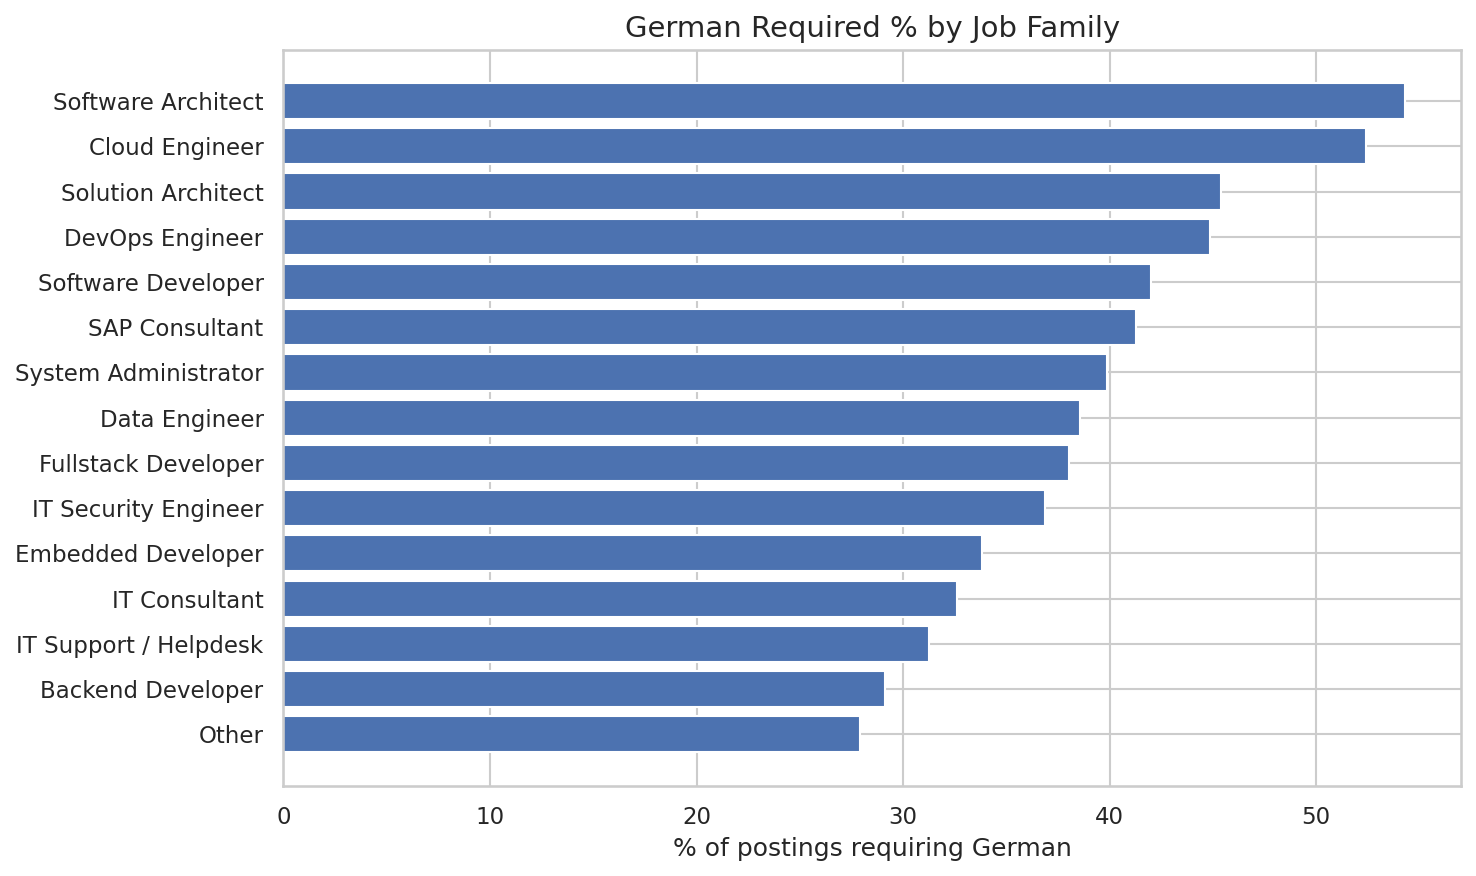

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def has_language(lang_json: object, language: str) -> bool:
    try:
        langs = json.loads(str(lang_json))
        return any(
            isinstance(lang, dict) and lang.get("language", "").lower() == language.lower()
            for lang in langs
        )
    except (json.JSONDecodeError, TypeError):
        return False

df2 = df.copy()
df2["has_german"] = df2["languages"].apply(lambda v: has_language(v, "german"))
top_families = df2["job_family"].value_counts().head(15).index

german_pct = (
    df2[df2["job_family"].isin(top_families)]
    .groupby("job_family")["has_german"]
    .mean()
    .sort_values()
    * 100
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(german_pct.index, german_pct.values)
ax.set_title("German Required % by Job Family")
ax.set_xlabel("% of postings requiring German")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "08_german_family.png", dpi=150)

## CEFR Level Distribution

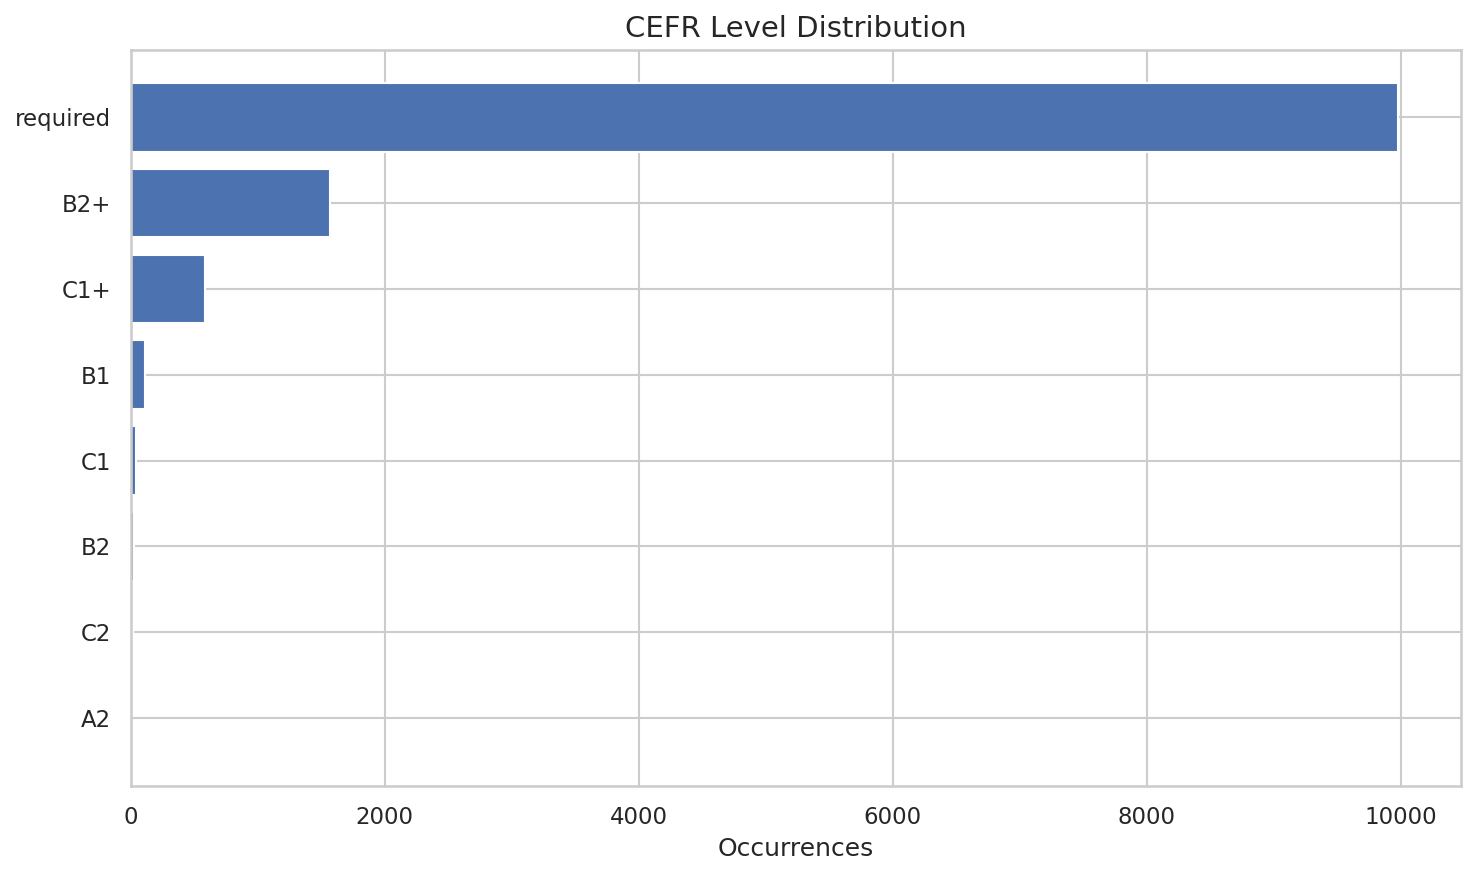

In [4]:
cefr_levels = []
for val in df["languages"]:
    try:
        langs = json.loads(str(val))
        for lang in langs:
            if isinstance(lang, dict) and lang.get("level"):
                cefr_levels.append(lang["level"])
    except (json.JSONDecodeError, TypeError):
        pass

cefr_series = pd.Series(cefr_levels)
horizontal_bar(
    cefr_series,
    "CEFR Level Distribution",
    xlabel="Occurrences",
    save_as="08_cefr_levels.png",
)

## English-Only Roles

English-only roles: 1,086 (5.7%)


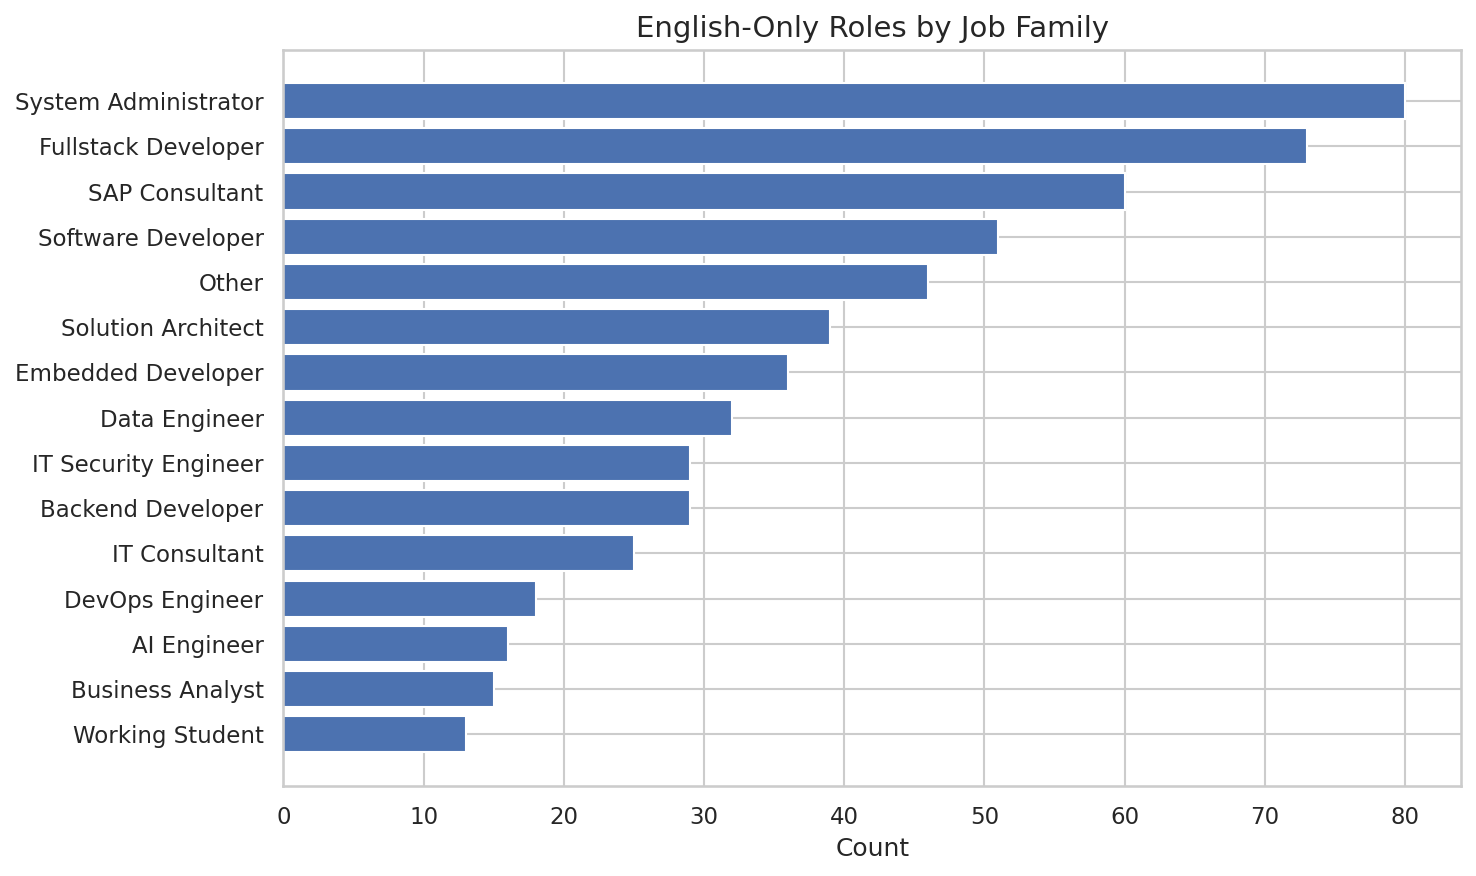

In [5]:
df3 = df.copy()
df3["has_english"] = df3["languages"].apply(lambda v: has_language(v, "english"))
df3["has_german"] = df3["languages"].apply(lambda v: has_language(v, "german"))

english_only = df3[df3["has_english"] & ~df3["has_german"]]
print(f"English-only roles: {len(english_only):,} ({len(english_only)/len(df)*100:.1f}%)")

horizontal_bar(
    english_only["job_family"],
    "English-Only Roles by Job Family",
    top_n=15,
    save_as="08_english_only.png",
)

## Language x Work Modality

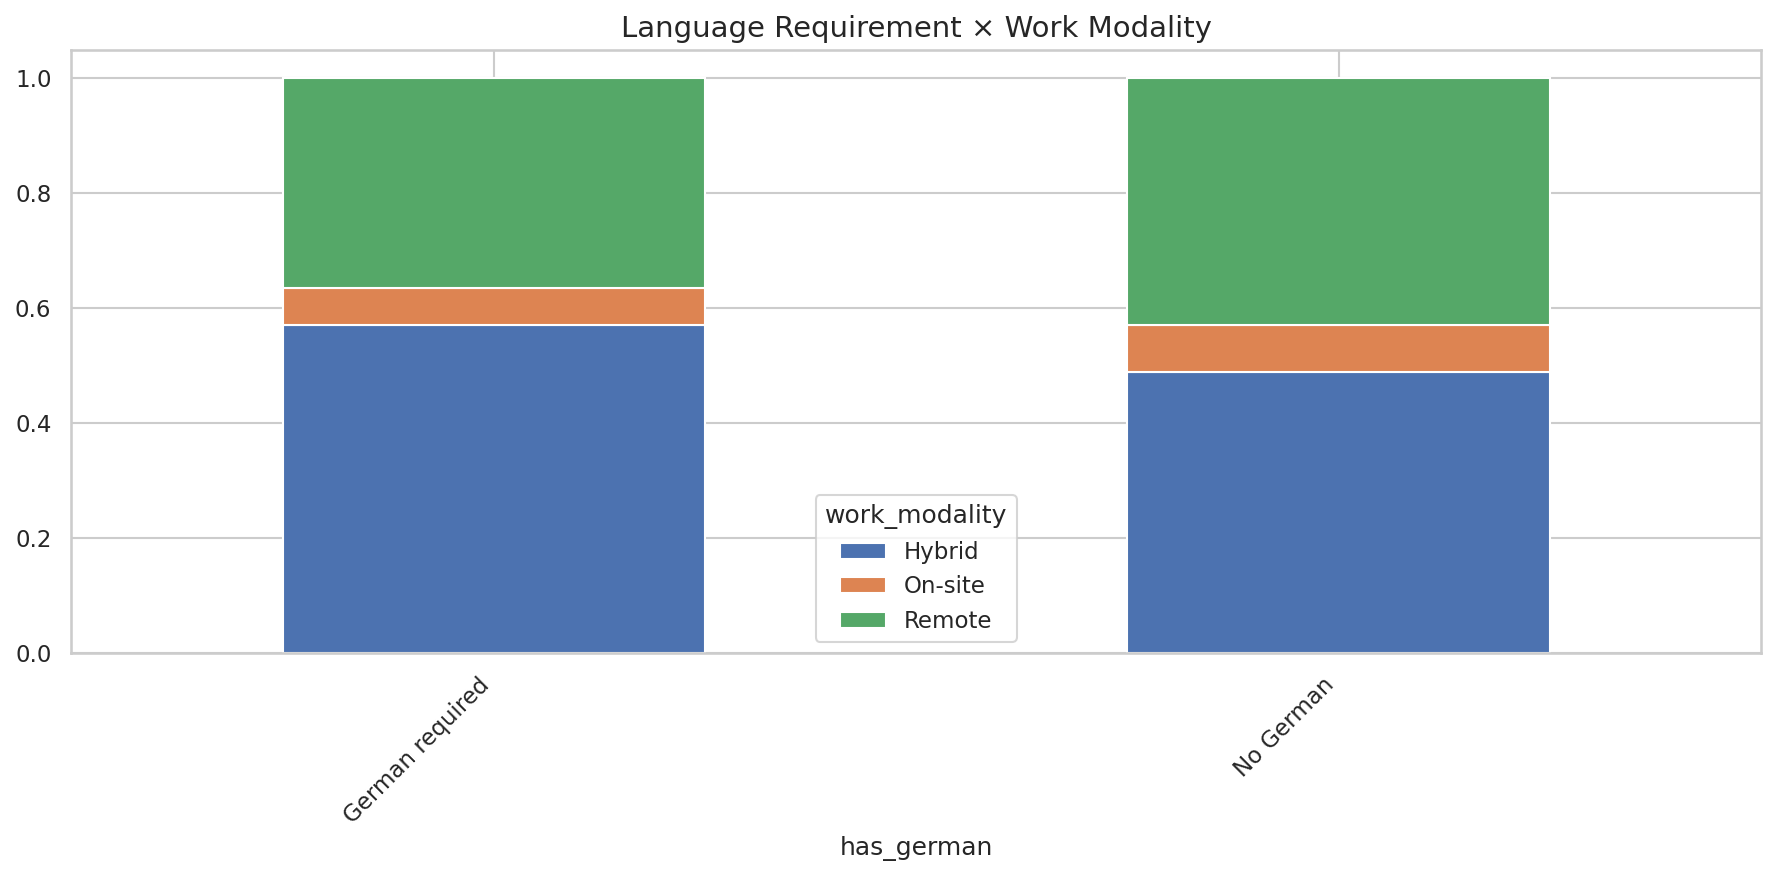

In [6]:
ct_lang_modality = pd.crosstab(
    df3["has_german"].map({True: "German required", False: "No German"}),
    df3["work_modality"],
    normalize="index",
)
stacked_bar(ct_lang_modality, "Language Requirement × Work Modality", save_as="08_lang_modality.png")